#### 1. 퍼셉트론의 한계와 이를 보완하기 위한 신경망의 등장
##### 1-1. 퍼셉트론의 한계
- 장점 : 층을 여러겹 쌓으면 컴퓨터가 처리하는 복잡한 처리도 표현할 수 있음
- 💥**단점 : 사람이 직접 수동으로 가중치값을 적절히 선택하는 작업을 함**

##### 1-2. 신경망의 등장
- 퍼셉트론의 한계(가중치를 직접 설정하는 것)을 해결하기 위해서 신경망이 등장함
- **신경망 = 가중치 매개변수의 적절한 값을 데이터로부터 자동으로 학습하는 능력을 가지고 있음**

#### 2. 퍼셉트론 vs 신경망
##### 2-0. 활성화 함수란?
- 입력 신호의 총합을 출력 신호로 변환하는 함수
- a = x1*w1 + x2*w2 + b(편향) ➡️ h(a) ➡️ h(a) < 0(return 0) / h(a) > 0(return 1)
- 위에서 활성화 함수는 h(_)가 되는 것

##### 2-1. 활성화함수의 차이
- 단층 퍼셉트론 : **계단 함수를 사용함.** 위 예시처럼 h(a) 값이 0을 넘느냐 못넘느냐를 기준으로 return 값이 0과 1로 나뉨.
- 신경망(다층 퍼셉트론) : **계단 함수 외의 다양한 활성화 함수를 사용함** / 시그모이드, ReLU 등

📍즉, **퍼셉트론 --- 다양한 활성화 함수 사용 ---> 신경망** 이라고 보면 됨.
📍활성화 함수 = 신경망으로 나아가는 열쇠

In [2]:
#계단 함수 구현(부동 소수점만 가능 / 넘파이 배열을 받아올 수 없음)
def step_function(x):
    if x > 0:
        return 1
    else:
        return 0

In [3]:
#계단 함수 구현(배열을 인수로 넣을 수 있도록)
def step_function(x):
    y = x > 0
    return y.astype(int)

#### 3. 활성화 함수 비교 : 계단 함수 vs 시그모이드 함수
##### 3-1. 공통점
- **둘 다 비선형 함수**
- 둘 다 활성화 함수로 사용하는 것
    - 계단 함수 = 단층 퍼셉트론에서 사용
    - 시그모이드 함수 = 신경망
- 입력이 중요하면 큰 값을 출력하고, 입력이 중요하지 않으면 작은 값을 출력
- 입력이 아무리 커도 출력은 0~1 사이의 값으로 구성
##### 3-2. 차이점
- 📍**퍼셉트론에서는 0 아니면 1의 값이 출력되고 신경망에서는 0~1사이의 연속적인 실수가 흐름**

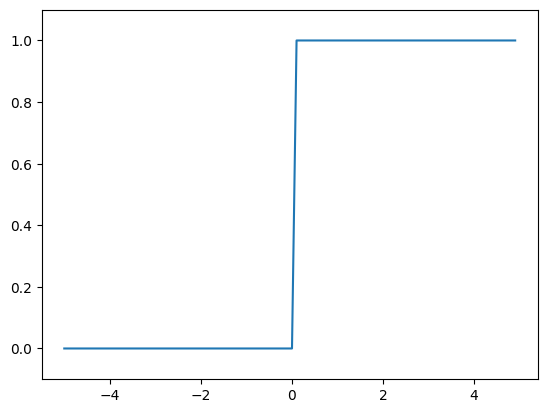

In [4]:
#계단 함수 그래프 구현
import numpy as np
import matplotlib.pylab as plt

def step_function(x):
    return np.array(x > 0, dtype=int)

x = np.arange(-5.0, 5.0, 0.1) #-5.0 부터 5.0까지 간격이 0.1인 배열 생성
y = step_function(x)
plt.plot(x,y) #x,y값을 가지고 그릴거고
plt.ylim(-0.1, 1.1) #y축의 범위 지정
plt.show()

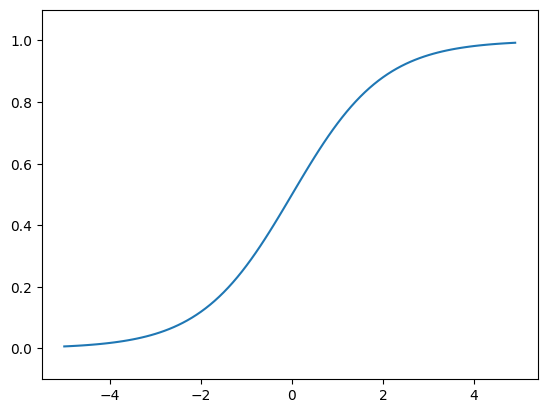

In [5]:
#시그모이드 함수 구현
def sigmoid(x):
    return 1/(1+np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x,y)
plt.ylim(-0.1, 1.1)
plt.show()

#### 4. 비선형 함수를 활성화 함수로 사용하는 이유?
✅ **선형 함수를 사용하면 신경망의 층을 깊게 하는 의미가 없어지기 때문**

만약... h(x) = k*x(단, k = 상수)를 활성화 함수로 사용한 3층 네트워크를 생각해보자.
그러면, 활성화 함수를 거친 값 y(x) = h(h(h(x)))가 될 것이고, 이는 y(x) = cxcxcxx 와 같다.
즉, y(x) = h(h(h(x))) = a*x와 같은 식이 될 것이다. (a = $c^3$ 인 상수처리 되기 때문에)
결론적으로, 은닉층이 없다고 할 수 있다. 
선형 함수를 사용해서는 여러 층으로 구성한 이점을 살릴 수 없다.

#### 5. ReLU(렐루) 함수
##### 입력이 0을 넘으면 그 입력을 그대로 출력하고, 0이하면 0을 출력하는 활성화 함수

In [6]:
def relu(x):
    return np.maximum(0, x) #0과 x중 더 큰 값을 반환

#### 6. 다차원 배열의 계산
- **넘파이의 다차원 배열을 사용한 계산법을 숙달하면, 신경망을 효율적으로 구현할 수 있음**
- 행렬의 곱은 np.dot(A, B)로 구현함.
- 이때, np.dot(A,B)와 np.dot(B,A)는 다를 수 있음
- 📍행렬 곱을 할 때는 행렬 A의 열 수와 행렬 B의 행 수가 일치해야함

In [7]:
A = np.array([[1,2,3],[4,5,6]])
print(A.shape)
B = np.array([[1,2],[3,4],[5,6]])
print(B.shape)
np.dot(A,B)

(2, 3)
(3, 2)


array([[22, 28],
       [49, 64]])

In [8]:
A = np.array([[1,2,3],[4,5,6]])
print(A.shape)
B = np.array([[1,2],[3,4],[5,6]])
print(B.shape)
np.dot(B,A)

(2, 3)
(3, 2)


array([[ 9, 12, 15],
       [19, 26, 33],
       [29, 40, 51]])

##### 6-1. 신경망에서의 행렬곱
- 편향과 활성화 함수를 생략하고 가중치만을 가지는 신경망을 넘바이 행렬을 통해 구현해보기
- 뉴런 = x1, x2 / 가중치 = (1,3,5),(2,4,6)
- 아래 코드에서 X, W, Y의 형상에 주의해서 보도록 하기!!!!!
    - X, W에 대응하는 차원의 원소수가 같아야한다는 것을 반드시 기억하기!!!!!

In [9]:
X = np.array([1,2])
print(X.shape)

W = np.array([[1,3,5],[2,4,6]])
print(W)
print(W.shape)

Y = np.dot(X, W)
print(Y)

(2,)
[[1 3 5]
 [2 4 6]]
(2, 3)
[ 5 11 17]


##### 6-2. 3층 신경망의 입력층 ➡️ 1층으로의 신호 전달 구현하기
- 편향(b)가 포함되어 있는 3층 신경망(은닉층이 2개인 신경망)에서의 신호 전달을 넘파이 배열로 구현해보자.
- 입력층 ➡️ 1층으로의 신호 전달을 기준으로 하면...
    - A = (a1, a2, a3) / X = (x1, x2) / B = (b1, b2, b3) / W = ((w1, w2, w3), (w4, w5, w6)) 이라고 할 때
    - A = XW + B 라고 표현이 가능함

In [10]:
X = np.array([1.0, 0.5]) #입력값
W1 = np.array([[0.1, 0.3, 0.5],[0.2, 0.4, 0.6]]) #입력값 ➡️ 1층으로 가는 가중치
B1 = np.array([0.1, 0.2, 0.3]) #1층으로 가는 편향

print(W1.shape)
print(X.shape)
print(B1.shape)

A1 = np.dot(X, W1) + B1
print(A1)

(2, 3)
(2,)
(3,)
[0.3 0.7 1.1]


In [11]:
#A1의 값 = 1층으로 넘어온 신호의 총합
#💥 이 A1의 값을 활성화 함수에 통과시키는 작업을 해야함
Z1 = sigmoid(A1) #활성화 함수는 시그모이드로 함

print(A1)
print(Z1)

[0.3 0.7 1.1]
[0.57444252 0.66818777 0.75026011]


##### 6-3. 3층 신경망의 1층 ➡️ 2층으로의 신호 전달 구현하기

In [12]:
W2 = np.array([[0.1, 0.4],[0.2, 0.5], [0.3, 0.6]])
B2 = np.array([0.1, 0.2])

print(Z1.shape)
print(W2.shape)
print(B2.shape)

A2 = np.dot(Z1, W2) + B2
Z2 = sigmoid(A2)

print(A2)
print(Z2)

(3,)
(3, 2)
(2,)
[0.51615984 1.21402696]
[0.62624937 0.7710107 ]


##### 6-4. 3층 신경망의 2층 ➡️ 출력층으로의 신호 전달 구현하기
- 출력층의 활성화 함수의 경우 풀고자하는 문제의 성질에 맞게 정의한다.
- **회귀 = 항등함수 / 2클래스 분류 = 시그모이드 함수 / 다중 클래스 분류 = 소프트맥스 함수**

In [13]:
def identity_function(x):
    return x

W3 = np.array([[0.1, 0.3], [0.2, 0.4]])
B3 = np.array([0.1, 0.2])

A3 = np.dot(Z2, W3) + B3
Y = identity_function(A3)

print(Y)

[0.31682708 0.69627909]


##### 6-5. 구현 정리 : 3층 신경망을 넘파이 배열의 행렬 곱으로 표현하기

In [ ]:
#가중치와 편항을 초기화 -> 딕셔너리 변수인 network에 저장
def init_network():
    network = {}
    network['W1'] = np.array([[0.1,0.3,0.5],[0.2,0.4,0.6]])
    network['b1'] = np.array([0.1,0.2,0.3])
    network['W2'] = np.array([[0.1,0.4],[0.2,0.5],[0.3,0.6]])
    network['b2'] = np.array([0.1,0.2])
    network['W3'] = np.array([[0.1,0.3],[0.2,0.4]])
    network['b3'] = np.array([0.1,0.2])

    return network

#순방향 입력의 과정을 나타내며, 입력신호를 출력으로 변환하는 처리과정을 담음
def forward(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y =  identity_function(a3)

    return y

network = init_network()
x = np.array([1.0,0.5])
y = forward(network, x)
print(y)

[0.31682708 0.69627909]


#### 7. 항등 함수와 소프트맥스 함수 구현하기
- 항등함수 = 입력을 그대로 출력함
- 소프트맥스 함수 = 분류 문제에서 사용 + 결과가 모든 클래스의 결과 합이 1인 소수로 나타남

In [17]:
def softmax(a):
    exp_a = np.exp(a)
    sum_exp_a = np.sum(exp_a)
    y - exp_a / sum_exp_a

    return Y

💥 **소프트맥스 함수의 경우는 지수 함수를 사용하는데, 지수 함수의 경우 오버플로 문제를 발생시킬 수 있음**
📍 그 결과, 수치가 **불안정**해질 수 있음
✅ 오버플로 문제를 방지하기 위해서 입력 신호 중 최댓값을 각 값에서 빼서 입력신호로 전달하는 방법을 고안

In [45]:
#여기서 'a = 배열'
def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a-c) #💥오버플로 대책
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a

    return y

##### 7-2. 소프트맥스 함수의 특징
- 소프트맥스 함수의 출력은 0~1 사이의 실수로, 출력의 총합은 1
- 그래서 소프트맥스 함수의 결과를 확률로 해석 가능함 ➡️ 문제를 통계적으로 대응할 수 있음

- 소프트맥스 함수를 적용해도 각 원소의 대소 관계는 변하지 않음(지수함수가 단조 증가 함수이기 때문에)
    - 그래서, 추론시(실제로 사용할 때)에는 출력층의 소프트맥스 함수를 생략함
    - 훈련시에는 반드시 출력층의 소프트맥스 함수를 사용

In [46]:
a = np.array([0.3, 2.9, 4.0])
y = softmax(a)
print(y)

np.sum(y)

[0.01821127 0.24519181 0.73659691]


np.float64(1.0)

#### 8. 손글씨 숫자 인식 with MNIST 데이터셋
- 이미 학습된 매개변수를 사용하여 학습과정은 생략하고 추론 과정만 함
- 0-9까지의 숫자 이미지로 구성
- 훈련 이미지 60,000장 + 테스트 이미지 10,000장
- 28x28 크기의 회색조 이미지(1채널)이며 각 픽셀은 0-255까지의 값을 취함

In [47]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
parent_dir = os.path.join(current_dir, '..')
sys.path.append(parent_dir)

from dataset.mnist import load_mnist

#flatten = 1x28x28 로 내보낼지, 평탄하게 1x784로 내보낼지 결정하는 변수
#normalize = 0-255값을 0-1 값 사이로 정규화 할지 말지
(x_train, t_train), (x_test, t_test) = load_mnist(flatten = True, normalize = False)

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [48]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
parent_dir = os.path.join(current_dir, '..')
sys.path.append(parent_dir)

from dataset.mnist import load_mnist
import numpy as np
from PIL import Image

def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))
    pil_img.show()

(x_train, t_train), (x_test, t_test) = load_mnist(flatten = True, normalize = False)

img = x_train[0] #훈련 이미지 1번
label = t_train[0] #훈련 이미지의 정답 레이블
print(label)

print(img.shape) #flatten = true 이므로... (784,)를 (28,28)로 리사이즈 해 줘야함
img = img.reshape(28,28)
print(img.shape)

img_show(img)


5
(784,)
(28, 28)


##### 8-1. MNIST 데이터셋을 이용한 신경망의 추론 처리
- 입력층 뉴런을 784개, 출력층 뉴런을 10개로 구성
    - 입력층 뉴런이 784인 이유 = 이미지 크기가 28x28=784이고, 출력층 뉴런이 10인 이유는 0-9까지의 숫자를 구분하는 문제이기 때문

- 은닉층은 총 2개이며 첫 번째 은닉층은 50개의 뉴런을, 두번째 은닉층에서는 100개의 뉴런을 배치
    - 해당 은닉층은 임의로 정한 것

In [49]:
import pickle
def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(flatten = True, normalize = True, one_hot_label = False)

    return x_test, t_test

def init_network():
    pkl_path = "../dataset/sample_weight.pkl"
    with open(pkl_path, "rb") as f:
        network = pickle.load(f)

    return network

def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y

In [50]:
x, t = get_data() #x = x_test, t = t_test
network = init_network()
#print(network['W1'].shape)

accuracy_cnt = 0
for i in range(len(x)): #test 이미지 10,000장을 하나씩 순회
    y = predict(network, x[i]) #test 이미지 10,000장 중 i번째 이미지를 network에 넣어서 예측
    p = np.argmax(y) #예측값이 0-9까지 총 10개에 대한 확률값으로 나오는데(softmax) 이 중에서 가장 큰 확률을 가진 번호 선택
    if p == t[i]: #만약, 레이블값이랑 같으면, 정확하게 예측했다고 카운트
        accuracy_cnt += 1

print("Accuracy: " + str(float(accuracy_cnt) / len(x)))

Accuracy: 0.9352


##### 8-2. 배치 처리
- 입력 데이터와 가중치 매개변수의 '형상'에 주의해서 다시 보기
- 위 코드에서는 이미지를 한장씩 predict()에 전달해서 처리했음
- 그런데, 이미지를 100장씩, 혹은 N장씩 묶어서 처리하면 어떻게 될까?
- 이렇게 **100장 혹은 n장씩 묶어서 처리하는 것을 '배치 처리' 라고 함**

In [ ]:
x, t = get_data()
network = init_network()

batch_size = 100 #100장씩 배치처리
accuracy_cnt = 0

for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size] #10,000장의 이미지를 100장씩 잘라서
    y_batch = predict(network, x_batch) #예측에 함께 보냄
    p = np.argmax(y_batch, axis = 1) #최댓값의 인덱스를 가지고 옴
    #예측한 배열과 레이블을 비교해서 True, false로 반환, true = 1이므로 일치하는 것의 총합을 구할 수 있음
    accuracy_cnt += np.sum(p == t[i:i+batch_size])

print("Accuracy: " + str(float(accuracy_cnt) / len(x)))

Accuracy: 0.9352
